# QoSBuddy – Root Cause Analysis (RCA) via Clustering

---

When a network problem is detected (by our teammate's anomaly detection model), the natural next question ia 'why?'

RCA answers that question by grouping IP addresses that show **similar behavioral patterns** — meaning they likely share the same root cause. For example:
- An IP sending mostly UDP traffic to thousands of destinations is probably involved in a **DDoS or scanning attack**
- An IP with almost all incoming traffic and high byte volume is likely **under a flood attack**
- An IP with normal protocol ratios but very high bytes is probably just experiencing **legitimate traffic congestion**

and here, we use unsupervised learning because we have unlabeled data and instead interpret from the cluster

---

### Why K-Means?
We considered two algorithms:

| Algorithm | Strength | Why Not Ideal Here |
|-----------|----------|--------------------|
| K-Means | Fast, interpretable, gives clean named groups | — |
| Hierarchical | Great for dendrograms | Too slow on many IPs; better for small datasets |

K-Means is the right tool because:
1. We want every IP assigned to a cause group — no IP should be left unlabeled
2. We want the groups to be interpretable and nameable such as ("congestion", "scanning", "flood")
3. It is fast enough to run across hundreds of IP.

---

### The Feature Logic — How We Diagnose Cause

The key insight is that different root causes leave different patterns across feature combinations:

| Feature Combination | What It Suggests |
|---------------------|------------------|
| High `n_bytes` + Low `dir_ratio` (incoming) | Flood / DDoS victim |
| High `n_dest_ip` + High `n_dest_port` + Low `tcp_udp_ratio` (UDP) | Port scanning or UDP flood (attacker) |
| High `n_flows` + High `tcp_udp_ratio` (TCP) + High `dir_ratio` (outgoing) | Botnet / C2 or server under SYN flood |
| High `n_bytes` + Balanced `dir_ratio` + High `tcp_udp_ratio` | Legitimate high-volume traffic (congestion) |
| Low everything | Normal / idle behavior |

We will engineer a **burstiness feature** to detect sudden volume spikes, and combine it with protocol and direction ratios to produce meaningful clusters.

---

## Section 1 — Import Libraries

We import standard data science libraries plus scikit-learn for clustering and PCA.

In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples, davies_bouldin_score
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
plt.rcParams['figure.dpi'] = 100

## Section 2 — Paths and Configuration

this is done using `ip_addresses_sample` instead of `ip_addresses_full`.

### Why 1-Hour Aggregation?
- **10 minutes**: Too noisy. A single spike looks like an attack. Normal behavior fluctuates too much.
- **1 hour** : Smooths out short noise while still capturing sustained behavioral patterns that indicate a root cause.
- **1 day**:  we might lose the shape of the problem entirely.

In [5]:
BASE_PATH = "C:/Users/muaad/Documents/Lists/esprit/4ds1/QoSBuddy/dataset"

IP_SAMPLE_PATH = os.path.join(BASE_PATH, "ip_addresses_sample")
TIMES_PATH     = os.path.join(BASE_PATH, "times")

# Aggregation level
AGG_FOLDER  = "agg_1_hour"
TIME_FILE   = "times_1_hour.csv"

print(f"IP sample path: {IP_SAMPLE_PATH}")
print(f"Aggregation  : {AGG_FOLDER}")

IP sample path: C:/Users/muaad/Documents/Lists/esprit/4ds1/QoSBuddy/dataset\ip_addresses_sample
Aggregation  : agg_1_hour


## Section 3 — Load All Sample IPs

Since we are using k-means, we have to load more than one IP at atime to be able to perform the clustering of the root causes especially since this is a telecommunications dataset

We load every CSV file in the sample folder, merge each one with the time index, and stack them all into one big DataFrame. Each row is one IP's behavior during one hour. This is the format K-Means needs.

**The `id_ip` column** is added so we can later trace which cluster each IP ended up in.

In [7]:
def load_all_sample_ips(sample_path, agg_folder, times_path, time_file, max_ips=None):
    """
    Load all IP CSVs from the sample folder, merge with time index,
    and stack into a single DataFrame.
    
    max_ips: if set, only load this many IPs (useful for quick testing).
             Set to None to load all available IPs in the sample.
    """
    folder = os.path.join(sample_path, agg_folder)
    csv_files = sorted([f for f in os.listdir(folder) if f.endswith('.csv')])
    
    if max_ips:
        csv_files = csv_files[:max_ips]
    
    print(f"Found {len(csv_files)} IP files in sample folder. Loading...")
    
    # Load the time reference table once
    times = pd.read_csv(os.path.join(times_path, time_file))
    
    all_dfs = []
    for fname in csv_files:
        ip_id = int(fname.replace('.csv', ''))
        fpath = os.path.join(folder, fname)
        
        df = pd.read_csv(fpath)
        df['id_ip'] = ip_id  # tag each row with its IP identifier
        df = df.merge(times, on='id_time', how='left')
        df['time'] = pd.to_datetime(df['time'], utc=True)
        df = df.sort_values('time').reset_index(drop=True)
        all_dfs.append(df)
    
    combined = pd.concat(all_dfs, ignore_index=True)
    print(f"Loaded {combined['id_ip'].nunique()} IPs → {combined.shape[0]} rows total.")
    return combined


# Load all sample IPs
# If this is still slow, set max_ips=100 for a quick test run
df_all = load_all_sample_ips(IP_SAMPLE_PATH, AGG_FOLDER, TIMES_PATH, TIME_FILE, max_ips=None)

df_all.head()

Found 1000 IP files in sample folder. Loading...
Loaded 1000 IPs → 1408879 rows total.


,id_time,n_flows,n_packets,n_bytes,sum_n_dest_asn,average_n_dest_asn,std_n_dest_asn,sum_n_dest_ports,average_n_dest_ports,std_n_dest_ports,sum_n_dest_ip,average_n_dest_ip,std_n_dest_ip,tcp_udp_ratio_packets,tcp_udp_ratio_bytes,dir_ratio_packets,dir_ratio_bytes,avg_duration,avg_ttl,id_ip,time
0,0,78,452,58128,60,10.00,1.79,70,11.67,1.86,68,11.33,1.51,0.94,0.96,0.52,0.58,1.88,123.72,100610,2023-10-09 00:00:00+00:00
1,1,81,327,40388,64,10.67,2.80,74,12.33,5.35,69,11.50,3.73,0.88,0.86,0.39,0.37,2.32,101.13,100610,2023-10-09 01:00:00+00:00
2,2,53,228,27508,49,8.17,1.83,52,8.67,2.34,51,8.50,2.51,0.90,0.88,0.44,0.51,2.62,109.75,100610,2023-10-09 02:00:00+00:00
3,3,48,235,32750,38,6.33,2.16,47,7.83,4.45,42,7.00,2.76,0.90,0.91,0.51,0.57,1.59,115.84,100610,2023-10-09 03:00:00+00:00
4,4,72,263,34248,42,7.00,2.90,70,11.67,6.25,45,7.50,2.88,0.84,0.78,0.61,0.64,4.00,85.58,100610,2023-10-09 04:00:00+00:00


## Section 4 — Data Validation

Before doing anything with the data, we always check:
1. Are there missing values? (Some IPs might have gaps in their time series)
2. Do the ranges make sense? (Ratios should be between 0 and 1)
3. What does the data look like at a glance?

This step is important because clustering is very sensitive to bad data. A single column full of NaN values will break the scaler and produce meaningless clusters.

In [9]:
print(f"Dataset shape: {df_all.shape}")
print(f"Unique IPs   : {df_all['id_ip'].nunique()}")
print(f"Time range   : {df_all['time'].min()}  →  {df_all['time'].max()}")
print()

# Check for missing values
null_counts = df_all.isnull().sum()
print("Missing values per column:")
print(null_counts[null_counts > 0] if null_counts.any() else "None — data is complete")

Dataset shape: (1408879, 21)
Unique IPs   : 1000
Time range   : 2023-10-09 00:00:00+00:00  →  2024-07-14 21:00:00+00:00

Missing values per column:
None — data is complete


In [10]:
# Quick sanity check: ratio columns should be in [0, 1]
ratio_cols = ['tcp_udp_ratio_packets', 'tcp_udp_ratio_bytes',
              'dir_ratio_packets', 'dir_ratio_bytes']

for col in ratio_cols:
    if col in df_all.columns:
        mn, mx = df_all[col].min(), df_all[col].max()
        status = "OK" if mn >= 0 and mx <= 1 else "OUT OF RANGE"
        print(f"{col}: min={mn:.4f}, max={mx:.4f}  {status}")

tcp_udp_ratio_packets: min=0.0000, max=1.0000  OK
tcp_udp_ratio_bytes: min=0.0000, max=1.0000  OK
dir_ratio_packets: min=0.0000, max=1.0000  OK
dir_ratio_bytes: min=0.0000, max=1.0000  OK


## Section 5 — Feature Engineering

Raw features alone are not enough. We need to engineer features that **capture the behavioral fingerprint** of each IP in a way that makes root causes distinguishable.

Here's what we add and why:

### a. Throughput
`throughput_bps = n_bytes * 8 / 3600`  
Converts bytes per hour into bits per second. This is the standard telecom unit and makes the scale more meaningful than raw byte counts.

### b. Burstiness Ratio
`burst_ratio = n_bytes / rolling_mean(n_bytes, 6 hours)`  
This asks: "Is this IP's current traffic much higher than its own recent average?"  
- A ratio of 1 = completely steady
- A ratio of 10 = 10x the normal volume — a spike

This is crucial for RCA because **attacks and congestion events are bursty**. A normal IP just runs steady.

### c. Destination Entropy (Spread)
`dest_spread = n_dest_ip + n_dest_port`  
An IP that contacts 5000 different destination IPs in one hour is almost certainly scanning. An IP that contacts 2-3 destinations is a normal client. This combined metric captures how "spread out" an IP's activity is.

### d. Protocol-Direction Interaction
`udp_outgoing = (1 - tcp_udp_ratio_packets) * dir_ratio_packets`  
This is the key "attack signature" feature. It multiplies:
- How much traffic is UDP (not TCP) — UDP is commonly used in flood attacks
- How outgoing the traffic is — attackers send, they don't receive

A high value here means: lots of UDP, mostly going out = likely attacker behavior.

### e. Log Normalization
Volume features (`n_bytes`, `n_packets`, `n_flows`) span many orders of magnitude — from 100 to 10 billion. If we don't compress this scale, K-Means will be dominated entirely by whichever IP has the highest byte count. `log1p(x)` compresses the scale while preserving relative differences.

In [12]:
def engineer_features(df):
    """
    Add RCA-relevant engineered features to the dataframe.
    We compute these PER IP (using groupby) so that rolling means
    don't bleed across different IPs.
    """
    df = df.copy()
    
    # 5a. Throughput (bits per second)
    df['throughput_bps'] = (df['n_bytes'] * 8) / 3600
    
    # 5b. Burstiness: current bytes vs 6-hour rolling average, computed per IP
    #     .transform() keeps the result aligned with the original index
    rolling_mean = (
        df.groupby('id_ip')['n_bytes']
        .transform(lambda x: x.rolling(window=6, min_periods=1).mean())
    )
    df['burst_ratio'] = df['n_bytes'] / (rolling_mean + 1)
    
    # 5c. Destination spread: how many different endpoints is this IP reaching?
    if 'sum_n_dest_ip' in df.columns and 'sum_n_dest_ports' in df.columns:
        df['dest_spread'] = df['sum_n_dest_ip'] + df['sum_n_dest_ports']
    elif 'n_dest_ip' in df.columns and 'n_dest_port' in df.columns:
        df['dest_spread'] = df['n_dest_ip'] + df['n_dest_port']
    else:
        df['dest_spread'] = 0
    
    # 5d. Protocol-direction interaction: high value = UDP + outgoing = attack signature
    df['udp_outgoing'] = (1 - df['tcp_udp_ratio_packets']) * df['dir_ratio_packets']
    
    # 5e. Log normalization of volume features to compress the scale
    for col in ['n_bytes', 'n_packets', 'n_flows', 'throughput_bps', 'dest_spread']:
        df[f'log_{col}'] = np.log1p(df[col])
    
    return df


df_all = engineer_features(df_all)

print("Feature engineering complete.")
print("New features added:")
new_cols = ['throughput_bps', 'burst_ratio', 'dest_spread', 'udp_outgoing',
            'log_n_bytes', 'log_n_packets', 'log_n_flows']
df_all[new_cols].describe().round(3)

Feature engineering complete.
New features added:


,throughput_bps,burst_ratio,dest_spread,udp_outgoing,log_n_bytes,log_n_packets,log_n_flows
count,1.408879e+06,1408879.000,1408879.000,1408879.000,1408879.000,1408879.000,1408879.000
mean,1.322537e+05,1.025,1755.961,0.120,10.674,5.648,3.785
std,1.167625e+06,1.061,17544.930,0.162,3.444,2.615,1.694
min,1.420000e-01,0.000,4.000,0.000,4.174,1.099,1.099
25%,6.249000e+00,0.335,23.000,0.000,7.942,3.738,2.708
50%,6.157300e+01,0.817,43.000,0.040,10.230,5.182,3.434
75%,5.789290e+02,1.256,91.000,0.189,12.470,6.876,4.357
max,1.317842e+08,6.000,384829.000,1.000,24.806,18.027,17.080


## Section 6 — Build IP Behavioral Profiles

**This is the most important conceptual step.**

Right now, our DataFrame has one row per hour per IP. If we cluster on this directly, we'd be clustering **time windows**, not IPs. That would tell us "which hours were similar" — not "which IPs have a similar root cause."

For RCA, we want to cluster **IPs**, not hours. To do that, we need to summarize each IP into a single row that captures its overall behavioral profile.

We do this with **per-IP aggregation**: for each IP, compute the mean and standard deviation of each feature across all time windows. This gives us:
- **Mean**: What is the typical behavior of this IP?
- **Std**: How variable/bursty is this IP's behavior?

The result is one row per IP with ~20 features. **This is what we cluster.**

In [14]:
# Features to summarize per IP
PROFILE_FEATURES = [
    'log_n_bytes',
    'log_n_packets',
    'log_n_flows',
    'log_throughput_bps',
    'tcp_udp_ratio_packets',
    'tcp_udp_ratio_bytes',
    'dir_ratio_packets',
    'dir_ratio_bytes',
    'log_dest_spread',
    'udp_outgoing',
    'burst_ratio',
    'std_n_dest_ip',
    'avg_ttl',
]

PROFILE_FEATURES = [f for f in PROFILE_FEATURES if f in df_all.columns]

# Aggregate: mean and std per IP
agg_mean = df_all.groupby('id_ip')[PROFILE_FEATURES].mean()
agg_std  = df_all.groupby('id_ip')[PROFILE_FEATURES].std().fillna(0)

# Rename std columns to avoid collision
agg_std.columns = [f'{c}_std' for c in agg_std.columns]

# Combine mean + std into one profile row per IP
ip_profiles = pd.concat([agg_mean, agg_std], axis=1)

print(f"IP profiles shape: {ip_profiles.shape}")
print(f"Each row = 1 IP, each column = a behavioral feature (mean or std)")
ip_profiles.head(3)

IP profiles shape: (1000, 26)
Each row = 1 IP, each column = a behavioral feature (mean or std)


,log_n_bytes,log_n_packets,log_n_flows,log_throughput_bps,tcp_udp_ratio_packets,tcp_udp_ratio_bytes,dir_ratio_packets,dir_ratio_bytes,log_dest_spread,udp_outgoing,burst_ratio,std_n_dest_ip,avg_ttl,log_n_bytes_std,log_n_packets_std,log_n_flows_std,log_throughput_bps_std,tcp_udp_ratio_packets_std,tcp_udp_ratio_bytes_std,dir_ratio_packets_std,dir_ratio_bytes_std,log_dest_spread_std,udp_outgoing_std,burst_ratio_std,std_n_dest_ip_std,avg_ttl_std
id_ip,,,,,,,,,,,,,,,,,,,,,,,,,,
11,17.162810,12.830692,11.979535,11.053579,0.001580,0.001304,0.506847,0.506290,12.323200,0.506045,1.003625,1147.790777,64.093695,0.446007,0.445357,0.286419,0.446001,0.004112,0.005057,0.052728,0.052798,0.231631,0.052696,0.271519,709.041474,1.847149
20,12.381277,6.731864,3.623668,6.278553,0.760689,0.695513,0.576269,0.536519,3.981694,0.143020,1.004315,1.886831,110.090643,1.335238,0.883469,0.687326,1.320881,0.171976,0.201789,0.141788,0.163483,0.578900,0.115011,0.905142,1.210384,29.226372
101,13.057621,6.858343,3.464245,6.952304,0.901589,0.892379,0.494224,0.412204,3.700460,0.048734,1.009760,3.302687,141.451296,1.754633,1.435152,0.585518,1.748316,0.120455,0.133072,0.122466,0.157932,0.467134,0.063210,1.324365,2.470953,18.182934


## Section 7 — Standardize the Feature Matrix

Even after log transformation, different features still live on very different scales.
For example:
- `log_n_bytes` might range from 5 to 20
- `tcp_udp_ratio_packets` ranges from 0 to 1
- `burst_ratio` might range from 1 to 50

K-Means uses **Euclidean distance** to measure similarity between points. If we don't standardize, the features with large ranges will completely dominate the distance calculation, and small but meaningful features like `dir_ratio` will be ignored.

`StandardScaler` transforms each feature to **mean=0, std=1**. Now every feature contributes equally to the clustering.

In [16]:
# Drop any remaining NaN rows (IPs with too few data points)
ip_profiles_clean = ip_profiles.dropna()
dropped = len(ip_profiles) - len(ip_profiles_clean)
if dropped > 0:
    print(f"⚠️  Dropped {dropped} IPs with missing values.")

scaler = StandardScaler()
X = scaler.fit_transform(ip_profiles_clean)

print(f"\n Feature matrix ready: {X.shape[0]} IPs × {X.shape[1]} features")
print(f"All features are now standardized to mean=0, std=1.")


 Feature matrix ready: 1000 IPs × 26 features
All features are now standardized to mean=0, std=1.


## Section 8 — Choosing the Number of Clusters (k)

K-Means requires us to decide in advance how many clusters (groups) we want. We use two methods together:

### Elbow Method
We run K-Means for k = 2, 3, 4, ... and plot the total inertia (sum of squared distances from each point to its cluster center). As k increases, inertia always decreases — but at some point, adding more clusters stops helping much. The "elbow" in the curve is where we should stop.

### Silhouette Score
For each k, we compute the silhouette score: a number between -1 and +1 that measures how well each IP fits its assigned cluster vs. the nearest other cluster.
- **+1** = perfectly in the right cluster
- **0** = on the boundary between two clusters
- **-1** = probably in the wrong cluster

We want the k where silhouette is highest.

**Practical guidance for RCA:** We expect to find roughly 4–6 meaningful groups (normal, congested, scanning/attack, flood victim, etc.). If the elbow is at k=3, that's fine — fewer, clearer groups are better than many vague ones.

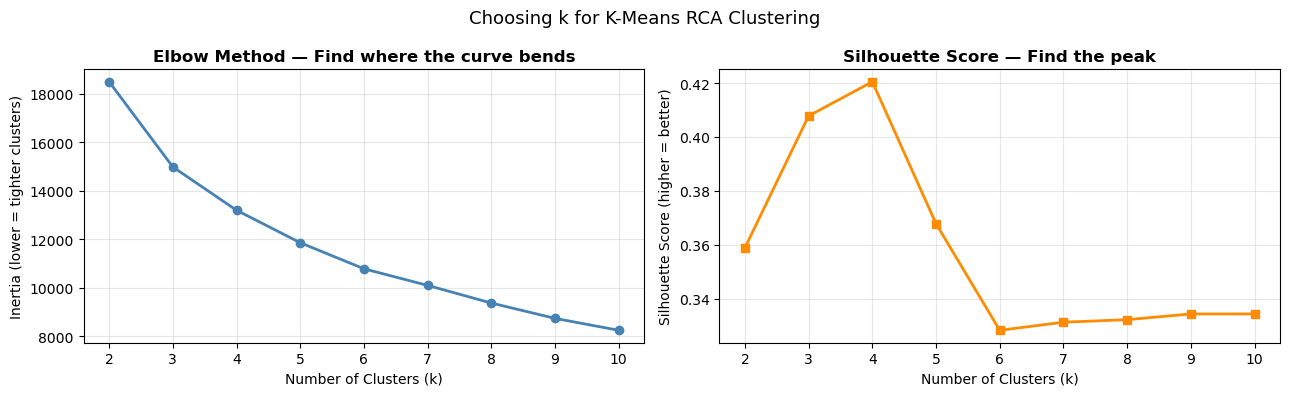


Best k by silhouette: k = 4  (score = 0.4205)
You can also visually inspect the elbow plot to choose k.
For RCA, prefer a k between 4 and 6 for interpretable cause groups.


In [18]:
k_range = range(2, 11)
inertias, silhouettes = [], []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X, labels))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(list(k_range), inertias, marker='o', color='steelblue', linewidth=2)
axes[0].set_title("Elbow Method — Find where the curve bends", fontweight='bold')
axes[0].set_xlabel("Number of Clusters (k)")
axes[0].set_ylabel("Inertia (lower = tighter clusters)")
axes[0].grid(alpha=0.3)

axes[1].plot(list(k_range), silhouettes, marker='s', color='darkorange', linewidth=2)
axes[1].set_title("Silhouette Score — Find the peak", fontweight='bold')
axes[1].set_xlabel("Number of Clusters (k)")
axes[1].set_ylabel("Silhouette Score (higher = better)")
axes[1].grid(alpha=0.3)

plt.suptitle("Choosing k for K-Means RCA Clustering", fontsize=13)
plt.tight_layout()
plt.show()

best_k = list(k_range)[silhouettes.index(max(silhouettes))]
print(f"\nBest k by silhouette: k = {best_k}  (score = {max(silhouettes):.4f})")
print("You can also visually inspect the elbow plot to choose k.")
print("For RCA, prefer a k between 4 and 6 for interpretable cause groups.")

## Section 9 — Fit the K-Means Model

We now fit K-Means with our chosen k. 

**Update `K_FINAL` below** based on the elbow and silhouette plots above. If both methods agree, use that k. If they disagree, prefer the elbow — silhouette can sometimes favor overly merged clusters.

`n_init=20` means K-Means will run 20 times with different random starting points and keep the best result. This avoids the problem of K-Means getting stuck in a bad local solution.

In [20]:
# ── SET THIS based on the elbow/silhouette plots above ─────────────────────
K_FINAL = 4  # Adjust after reading the plots
# ───────────────────────────────────────────────────────────────────────────

km_final = KMeans(n_clusters=K_FINAL, random_state=42, n_init=20)
cluster_labels = km_final.fit_predict(X)

# Attach cluster labels back to the IP profiles
ip_profiles_clean = ip_profiles_clean.copy()
ip_profiles_clean['cluster'] = cluster_labels

sil = silhouette_score(X, cluster_labels)
dbi = davies_bouldin_score(X, cluster_labels)

print(f"K-Means fitted with k = {K_FINAL}")
print(f"Silhouette Score : {sil:.4f}  (closer to 1.0 = better separation)")
print(f"Davies-Bouldin   : {dbi:.4f}  (closer to 0.0 = better separation)")
print()
print("Cluster sizes:")
print(ip_profiles_clean['cluster'].value_counts().sort_index())

K-Means fitted with k = 4
Silhouette Score : 0.4146  (closer to 1.0 = better separation)
Davies-Bouldin   : 1.0686  (closer to 0.0 = better separation)

Cluster sizes:
cluster
0      3
1    111
2    353
3    533
Name: count, dtype: int64


## Section 10 — Interpret the Clusters: What Is Each Root Cause?

This is the most important step in RCA. We don't just want cluster numbers — we want to **name the cause**.

We look at the **mean value of each feature per cluster** and compare them to understand what behavioral profile each cluster represents.

**How to read the table:**
- A cluster with high `burst_ratio` and low `tcp_udp_ratio` (more UDP) → likely attack-related
- A cluster with high `log_n_bytes` but balanced `dir_ratio` (~0.5) → high-volume but legitimate (congestion)
- A cluster with high `log_dest_spread` and high `udp_outgoing` → scanning or DDoS source
- A cluster with low `dir_ratio` (mostly incoming) and high bytes → flood victim
- A cluster with low everything → normal / idle

In [22]:
# Key interpretive features — these are the ones that reveal root cause
INTERPRET_COLS = [
    'log_n_bytes', 'log_n_flows',
    'tcp_udp_ratio_packets', 'dir_ratio_packets',
    'log_dest_spread', 'udp_outgoing', 'burst_ratio'
]
INTERPRET_COLS = [c for c in INTERPRET_COLS if c in ip_profiles_clean.columns]

cluster_profiles = ip_profiles_clean.groupby('cluster')[INTERPRET_COLS].mean().round(3)

print("=== Cluster Behavioral Profiles ===")
print("Read each row as: 'IPs in cluster X have these average characteristics'")
print()
display(cluster_profiles)

print()
print("Interpretation guide:")
print("  log_n_bytes       : higher = more traffic volume")
print("  tcp_udp_ratio     : 1=all TCP, 0=all UDP (UDP heavy = suspicious)")
print("  dir_ratio_packets : 1=all outgoing, 0=all incoming")
print("  log_dest_spread   : higher = contacts more unique destinations/ports")
print("  udp_outgoing      : combined attack signal (high = UDP + outgoing)")
print("  burst_ratio       : higher = traffic spikes sharply above own baseline")

=== Cluster Behavioral Profiles ===
Read each row as: 'IPs in cluster X have these average characteristics'



,log_n_bytes,log_n_flows,tcp_udp_ratio_packets,dir_ratio_packets,log_dest_spread,udp_outgoing,burst_ratio
cluster,,,,,,,
0,16.992,8.538,0.526,0.585,8.914,0.249,1.039
1,8.818,3.665,0.422,0.448,3.961,0.265,1.010
2,7.376,2.265,0.977,0.458,2.759,0.010,1.021
3,11.979,3.315,0.898,0.488,3.594,0.049,1.029



Interpretation guide:
  log_n_bytes       : higher = more traffic volume
  tcp_udp_ratio     : 1=all TCP, 0=all UDP (UDP heavy = suspicious)
  dir_ratio_packets : 1=all outgoing, 0=all incoming
  log_dest_spread   : higher = contacts more unique destinations/ports
  udp_outgoing      : combined attack signal (high = UDP + outgoing)
  burst_ratio       : higher = traffic spikes sharply above own baseline


## Section 11 — Assigning Human-Readable Root Cause Labels

After reading the profile table above, map each cluster number to a meaningful cause label.

**Edit the `CAUSE_LABELS` dictionary below** to match what you observe in your profiles.

Common labels to choose from:
- `"normal"` — low everything, typical background traffic
- `"congestion"` — high bytes, balanced direction, high TCP
- `"scan_or_ddos_source"` — high dest_spread, high udp_outgoing, high burst
- `"flood_victim"` — high incoming bytes (low dir_ratio), high burst
- `"heavy_uploader"` — high outgoing (high dir_ratio), high bytes, normal TCP

Root Cause Distribution across all IPs:


,count,pct
cause_label,,
congestion,533,53.3
normal,353,35.3
udp_suspicious,111,11.1
extreme_scanner,3,0.3


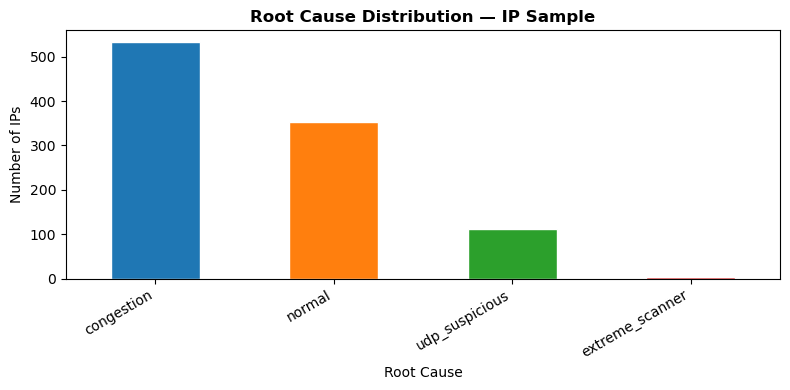

In [24]:
# ── EDIT THIS after reading the profile table in Section 10 ────────────────
CAUSE_LABELS = {
    0: "extreme_scanner",   
    1: "udp_suspicious",    
    2: "normal",            
    3: "congestion",        
}
# ───────────────────────────────────────────────────────────────────────────

ip_profiles_clean['cause_label'] = ip_profiles_clean['cluster'].map(CAUSE_LABELS)

print("Root Cause Distribution across all IPs:")
label_counts = ip_profiles_clean['cause_label'].value_counts()
display(label_counts.to_frame('count').assign(pct=lambda x: (x['count']/len(ip_profiles_clean)*100).round(1)))

# Visual: bar chart of cause distribution
plt.figure(figsize=(8, 4))
label_counts.plot(kind='bar', color=sns.color_palette('tab10', len(label_counts)), edgecolor='white')
plt.title("Root Cause Distribution — IP Sample", fontweight='bold')
plt.xlabel("Root Cause")
plt.ylabel("Number of IPs")
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## Section 12 — Visualize Clusters in 2D (PCA)

Our feature matrix has ~20 dimensions. We can't plot 20D data directly. **PCA (Principal Component Analysis)** reduces it to 2 dimensions while preserving as much of the structure as possible.

Think of PCA as taking a photograph of a 3D object from the best angle — you lose one dimension, but you can still see the overall shape.

If the clusters are well-separated in the 2D plot, it means K-Means found genuinely distinct groups. Overlapping clusters in the plot would suggest the groups are not very different from each other (and we might need to revisit our k or features).

PCA: PC1 explains 36.4%, PC2 explains 17.9% of variance
Together: 54.3% of total variance preserved in 2D


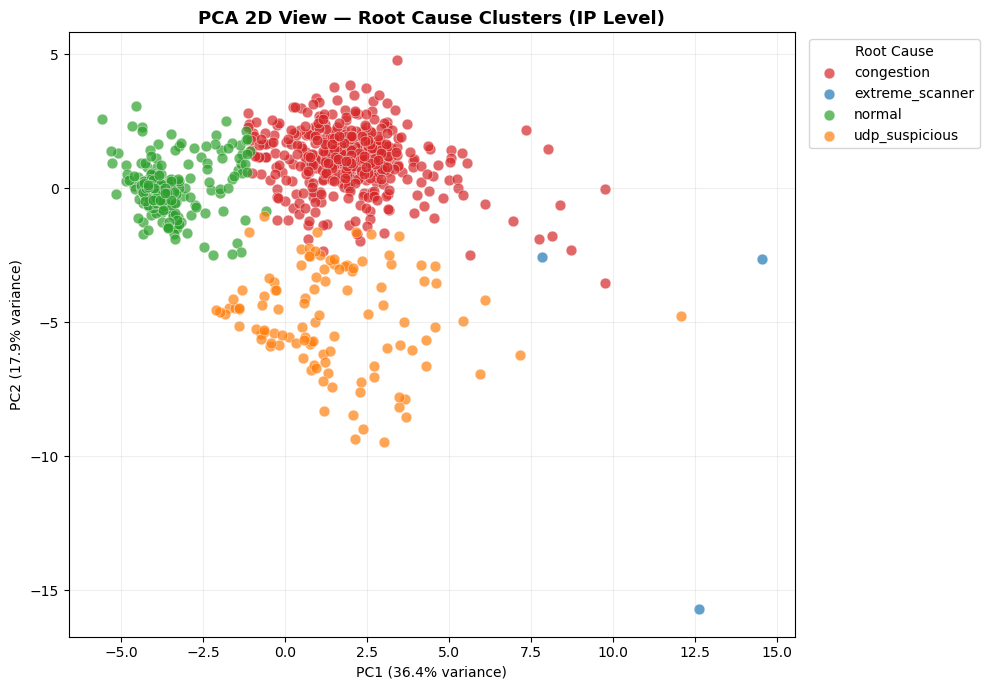

In [26]:
pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X)

explained = pca.explained_variance_ratio_
print(f"PCA: PC1 explains {explained[0]:.1%}, PC2 explains {explained[1]:.1%} of variance")
print(f"Together: {sum(explained):.1%} of total variance preserved in 2D")

# Build a plot DataFrame
plot_df = pd.DataFrame({
    'PC1': X_2d[:, 0],
    'PC2': X_2d[:, 1],
    'cause': ip_profiles_clean['cause_label'].values
})

palette = dict(zip(CAUSE_LABELS.values(), sns.color_palette('tab10', len(CAUSE_LABELS))))

plt.figure(figsize=(10, 7))
for cause, grp in plot_df.groupby('cause'):
    plt.scatter(grp['PC1'], grp['PC2'],
                label=cause, color=palette.get(cause, 'gray'),
                s=60, alpha=0.7, edgecolors='white', linewidths=0.4)

plt.title("PCA 2D View — Root Cause Clusters (IP Level)", fontsize=13, fontweight='bold')
plt.xlabel(f"PC1 ({explained[0]:.1%} variance)")
plt.ylabel(f"PC2 ({explained[1]:.1%} variance)")
plt.legend(title="Root Cause", bbox_to_anchor=(1.01, 1), loc='upper left')
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## Section 13 — Silhouette Plot

The silhouette plot gives us a per-IP view of cluster quality — not just an average score.

Each bar represents one IP. The width of the bar is its silhouette score:
- **Wide bar (positive)**: This IP is clearly in the right cluster
- **Thin bar (near 0)**: This IP is on the boundary — could belong to another cluster
- **Negative bar**: This IP may be misclustered

A good clustering result has most bars positive and roughly similar heights within each cluster.

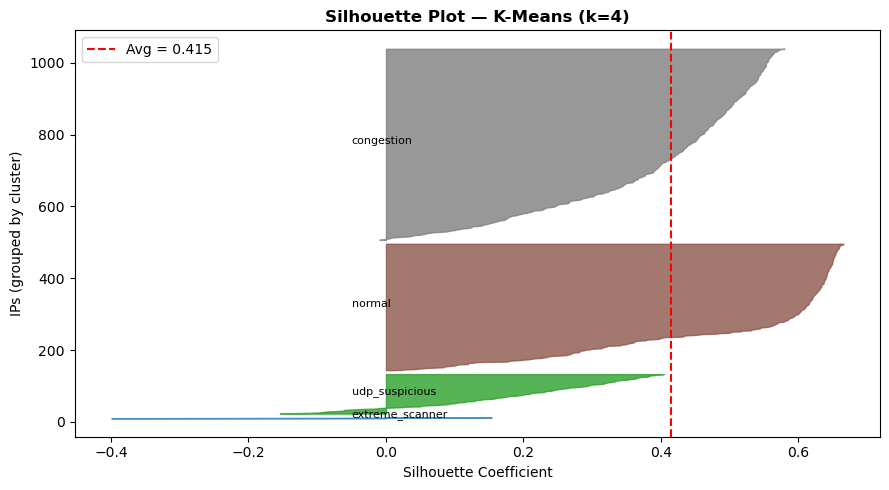

In [28]:
sample_sil_vals = silhouette_samples(X, cluster_labels)
fig, ax = plt.subplots(figsize=(9, 5))
y_lower = 10

for i in range(K_FINAL):
    ith_vals = np.sort(sample_sil_vals[cluster_labels == i])
    size_i = ith_vals.shape[0]
    y_upper = y_lower + size_i
    color = cm.tab10(float(i) / K_FINAL)
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_vals,
                     facecolor=color, edgecolor=color, alpha=0.8)
    label = CAUSE_LABELS.get(i, str(i))
    ax.text(-0.05, y_lower + 0.5 * size_i, label, fontsize=8)
    y_lower = y_upper + 10

ax.axvline(x=sil, color='red', linestyle='--', label=f'Avg = {sil:.3f}')
ax.set_title(f"Silhouette Plot — K-Means (k={K_FINAL})", fontweight='bold')
ax.set_xlabel("Silhouette Coefficient")
ax.set_ylabel("IPs (grouped by cluster)")
ax.legend()
plt.tight_layout()
plt.show()

## Section 14 — Feature Importance: What Drives Each Cause?

Now we go deeper: which features are most responsible for separating the clusters?

We look at the **cluster centroids** (the center point of each cluster in feature space) transformed back to interpretable scale, and plot a heatmap. The heatmap shows:
- **Dark red** = This cluster has a very high value of this feature
- **Dark blue** = This cluster has a very low value of this feature

This directly answers the question: "What makes a flood victim look different from a scanner?"

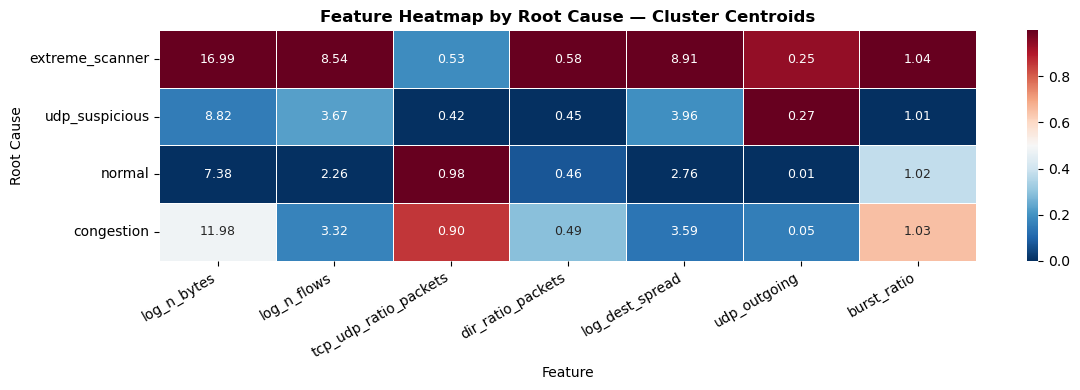


Read the heatmap: dark red = high value, dark blue = low value.
Each row tells you what makes that root cause distinctive.


In [30]:
# Get centroids in the original (unscaled) profile feature space
centroid_df = ip_profiles_clean.groupby('cluster')[INTERPRET_COLS].mean()
centroid_df.index = [CAUSE_LABELS.get(i, str(i)) for i in centroid_df.index]

# Normalize each column to [0,1] for visual comparison
centroid_norm = (centroid_df - centroid_df.min()) / (centroid_df.max() - centroid_df.min() + 1e-9)

plt.figure(figsize=(12, 4))
sns.heatmap(centroid_norm, annot=centroid_df.round(2), fmt='.2f',
            cmap='RdBu_r', linewidths=0.5,
            annot_kws={'size': 9})
plt.title("Feature Heatmap by Root Cause — Cluster Centroids", fontweight='bold', fontsize=12)
plt.ylabel("Root Cause")
plt.xlabel("Feature")
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

print("\nRead the heatmap: dark red = high value, dark blue = low value.")
print("Each row tells you what makes that root cause distinctive.")

## Section 15 — Root Cause Analysis Report

This is the final deliverable of the RCA pipeline.

For each IP, the report answers **four questions** — and nothing else:

1. **What is the cause?** — A plain-English classification of the behaviour type.
2. **What does it mean?** — What this behaviour actually looks like in the real world, with no technical jargon.
3. **Why do we think this?** — The specific observations from the data that led to this classification, written as human-readable sentences.
4. **Is this chronic or new?** — Whether this is a long-standing pattern or a recent shift, and how many other IPs share the same cause.

**What this report does NOT include:**
- When the anomaly occurred (that is the anomaly detection report's job)
- What action to take (that is the anomaly detection report's job)
- Raw numbers or model metrics (those are in Sections 10–14)

This report is designed to be served directly from the FastAPI  endpoint and rendered in the Power BI dashboard when the user clicks "View Root Cause" on a flagged anomaly.

In [32]:
import json
from datetime import datetime

# ── Plain-English cause descriptions ─────────────────────────────────────────
# Each cause has a title, a plain explanation, and the evidence signals.
# NO recommended actions — that belongs to the anomaly detection report.

CAUSE_DESCRIPTIONS = {
    "extreme_scanner": {
        "title": "Extreme Traffic Scanner",
        "what_it_means": (
            "This device is reaching out to an extraordinarily large number of "
            "different destinations and ports every hour — far beyond what any "
            "normal computer, phone, or server would ever do. It is behaving "
            "like something that is deliberately trying to map or probe the "
            "network, or it is part of a larger attack originating from this IP."
        ),
        "evidence_template": [
            "contacts_destinations",
            "protocol_mix",
            "direction",
            "burstiness",
            "persistence",
            "peer_comparison",
        ],
    },
    "udp_suspicious": {
        "title": "Unusual Outbound UDP Traffic",
        "what_it_means": (
            "This device is sending a higher-than-normal amount of UDP traffic "
            "outward into the network. UDP is a protocol that does not require "
            "a formal connection — it just sends data without checking if anyone "
            "is listening. While UDP has normal uses like video calls and DNS, "
            "the pattern here is tilted enough away from the norm to stand out "
            "from the rest of the network population."
        ),
        "evidence_template": [
            "protocol_mix",
            "direction",
            "contacts_destinations",
            "burstiness",
            "persistence",
            "peer_comparison",
        ],
    },
    "congestion": {
        "title": "High Volume — Likely Congestion Source",
        "what_it_means": (
            "This device is consistently one of the heaviest traffic generators "
            "on the network. There is nothing suspicious about how it communicates "
            "— the protocol mix and direction look completely normal — but the "
            "sheer amount of data it moves every hour puts it in a different "
            "category from most other devices. When multiple IPs like this are "
            "active at the same time, they can slow down the network for everyone."
        ),
        "evidence_template": [
            "volume",
            "protocol_mix",
            "direction",
            "burstiness",
            "persistence",
            "peer_comparison",
        ],
    },
    "normal": {
        "title": "Normal Baseline Behaviour",
        "what_it_means": (
            "This device behaves exactly as expected for a standard user on this "
            "network. Its traffic volume, the mix of protocols it uses, and the "
            "range of destinations it contacts are all within the normal range "
            "observed across this network. If an anomaly was flagged for this IP, "
            "it was most likely a short-lived and isolated event rather than a "
            "persistent underlying problem."
        ),
        "evidence_template": [
            "volume",
            "protocol_mix",
            "direction",
            "contacts_destinations",
            "burstiness",
            "peer_comparison",
        ],
    },
}


# ── Translate raw feature values into plain-English observations ──────────────
def build_observations(row, evidence_template):
    """
    Convert profile numbers into human sentences based on which
    evidence signals are relevant for this cause type.
    Returns a list of plain-English observation strings.
    """
    obs = {}

    # Volume
    log_bytes = row.get("log_n_bytes", 0)
    if log_bytes > 14:
        obs["volume"] = "It moves an extremely large amount of data every hour — placing it among the very heaviest users on this network."
    elif log_bytes > 11:
        obs["volume"] = "It moves a high amount of data every hour — well above what most devices on this network do."
    elif log_bytes < 8:
        obs["volume"] = "It moves a relatively small amount of data — consistent with a light-use device like a phone or occasional-use computer."
    else:
        obs["volume"] = "Its data volume is moderate and sits within the expected range for a typical active device."

    # Protocol mix
    tcp_ratio = row.get("tcp_udp_ratio_packets", 1.0)
    if tcp_ratio < 0.2:
        obs["protocol_mix"] = "Almost all of its traffic uses UDP — this is highly unusual for a standard device and is one of the strongest signals in its profile."
    elif tcp_ratio < 0.5:
        obs["protocol_mix"] = "A significant portion of its traffic uses UDP, which is more than what most normal devices send."
    elif tcp_ratio < 0.8:
        obs["protocol_mix"] = "It uses a mix of TCP and UDP, leaning toward TCP — slightly more UDP than a typical device."
    else:
        obs["protocol_mix"] = "It communicates almost entirely over TCP, which is the standard protocol for web browsing, email, and most everyday applications."

    # Direction
    dir_ratio = row.get("dir_ratio_packets", 0.5)
    if dir_ratio > 0.75:
        obs["direction"] = "The vast majority of its traffic is outgoing — it sends much more than it receives, which is unusual for a client device."
    elif dir_ratio > 0.6:
        obs["direction"] = "Its traffic leans outbound — it sends noticeably more than it receives."
    elif dir_ratio < 0.25:
        obs["direction"] = "The vast majority of its traffic is incoming — it receives far more than it sends, which can indicate it is a target rather than a source."
    elif dir_ratio < 0.4:
        obs["direction"] = "Its traffic leans inbound — it receives noticeably more than it sends."
    else:
        obs["direction"] = "Its traffic is well balanced between sending and receiving — consistent with normal two-way communication."

    # Destination spread
    log_dest = row.get("log_dest_spread", 0)
    if log_dest > 8:
        obs["contacts_destinations"] = "It contacts a massive number of unique destinations and ports — far beyond what any normal device would reach in normal usage."
    elif log_dest > 5:
        obs["contacts_destinations"] = "It reaches a wider-than-average range of destinations, which is worth noting even if not extreme."
    else:
        obs["contacts_destinations"] = "It communicates with a small and consistent set of destinations — normal for a device with regular, predictable usage patterns."

    # Burstiness
    burst = row.get("burst_ratio", 1.0)
    if burst > 3.0:
        obs["burstiness"] = "Its traffic spikes dramatically at times — several times higher than its own average — suggesting sudden surges of activity."
    elif burst > 1.8:
        obs["burstiness"] = "Its traffic volume is noticeably uneven, with regular spikes above its own baseline."
    else:
        obs["burstiness"] = "Its traffic volume is relatively steady over time, without dramatic spikes or drops."

    # Persistence (using std of log_n_bytes as proxy for consistency)
    std_bytes = row.get("log_n_bytes_std", 1.0)
    if std_bytes < 0.5:
        obs["persistence"] = "This pattern has been extremely consistent across the entire monitoring period — this is not a one-off event, it is how this device always behaves."
    elif std_bytes < 1.2:
        obs["persistence"] = "This pattern has been fairly consistent over time, suggesting it reflects the device's normal operating behaviour rather than a temporary event."
    else:
        obs["persistence"] = "This device's behaviour varies quite a bit over time, which means the current pattern may be a recent shift rather than a long-standing habit."

    return [obs[key] for key in evidence_template if key in obs]


# ── Peer context: how many other IPs share this cause ────────────────────────
def build_peer_context(id_ip, cause_label, ip_profiles_clean):
    """
    Tell the reader how many other IPs share the same root cause,
    and whether this IP is a typical or extreme example of its group.
    """
    group = ip_profiles_clean[ip_profiles_clean["cause_label"] == cause_label]
    total_ips = len(ip_profiles_clean)
    group_size = len(group)
    pct = round(group_size / total_ips * 100, 1)

    # Is this IP more or less extreme than the group average?
    group_mean_bytes = group["log_n_bytes"].mean()
    this_bytes = ip_profiles_clean.loc[id_ip, "log_n_bytes"]
    if this_bytes > group_mean_bytes + 1.5:
        position = "and is one of the more extreme examples within this group"
    elif this_bytes < group_mean_bytes - 1.5:
        position = "and sits on the milder end of this group"
    else:
        position = "and is a fairly typical representative of this group"

    return (
        f"{group_size} out of {total_ips} IPs on this network ({pct}%) "
        f"share the same root cause classification, {position}."
    )


# ── Chronic vs new: compare recent behaviour to full-period average ───────────
def build_chronicity(id_ip, df_all):
    """
    Compare the IP's traffic in the most recent 2 weeks vs its full history
    to determine whether this is a persistent pattern or a recent change.
    """
    ip_data = df_all[df_all["id_ip"] == id_ip].sort_values("time")
    if len(ip_data) < 20:
        return "There is not enough historical data for this IP to determine whether this is a new or long-standing pattern."

    cutoff = ip_data["time"].max() - pd.Timedelta(weeks=2)
    recent = ip_data[ip_data["time"] >= cutoff]
    historic = ip_data[ip_data["time"] < cutoff]

    if len(recent) < 5 or len(historic) < 5:
        return "Insufficient data in one of the time windows to make a reliable comparison."

    recent_mean = recent["n_bytes"].mean()
    historic_mean = historic["n_bytes"].mean()

    if historic_mean == 0:
        return "This device had no prior traffic history — its current behaviour appears to be entirely new."

    change_pct = ((recent_mean - historic_mean) / historic_mean) * 100

    if change_pct > 80:
        return (
            f"This behaviour appears to be NEW. Traffic in the past two weeks is "
            f"roughly {abs(round(change_pct))}% higher than the device's historical average, "
            f"which suggests something changed recently — possibly a new application, "
            f"a configuration change, or the start of a new type of activity."
        )
    elif change_pct < -60:
        return (
            f"This device has become significantly quieter recently — traffic dropped "
            f"roughly {abs(round(change_pct))}% compared to its historical average. "
            f"This could mean the problem has partially resolved, or the device is less active."
        )
    else:
        return (
            f"This behaviour is CHRONIC. Traffic levels in the past two weeks are "
            f"broadly consistent with the device's long-term average (within {abs(round(change_pct))}%), "
            f"which means this pattern has been present for an extended period — "
            f"it is not a recent development."
        )


# ── Main report generator ─────────────────────────────────────────────────────
def generate_rca_report(id_ip, ip_profiles_clean, df_all):
    """
    Generate a complete human-readable RCA report for one IP.
    Covers: cause, what it means, why we think this, and chronic vs new.
    Does NOT cover: when, where, or what action to take.
    """
    if id_ip not in ip_profiles_clean.index:
        return {"error": f"IP {id_ip} not found in RCA output."}

    row        = ip_profiles_clean.loc[id_ip]
    cause      = row["cause_label"]
    definition = CAUSE_DESCRIPTIONS.get(cause, {})
    template   = definition.get("evidence_template", [])

    observations = build_observations(row, template)
    peer_context = build_peer_context(id_ip, cause, ip_profiles_clean)
    chronicity   = build_chronicity(id_ip, df_all)

    return {
        "id_ip"         : int(id_ip),
        "report_type"   : "Root Cause Analysis",
        "generated_at"  : datetime.utcnow().strftime("%Y-%m-%d %H:%M UTC"),
        "cause_label"   : cause,
        "cause_title"   : definition.get("title", cause),
        "what_it_means" : definition.get("what_it_means", ""),
        "why_we_think_this" : observations,
        "chronic_or_new": chronicity,
        "peer_context"  : peer_context,
    }


# ── Pretty printer ────────────────────────────────────────────────────────────
def print_rca_report(report):
    if "error" in report:
        print(f"Error: {report["error"]}")
        return

    sep  = "=" * 64
    dash = "-" * 64

    print(sep)
    print("  ROOT CAUSE ANALYSIS REPORT")
    print(f"  IP Address  : {report["id_ip"]}")
    print(f"  Generated   : {report["generated_at"]}")
    print(sep)

    print()
    print("  1. CAUSE CLASSIFICATION")
    print(dash)
    print(f"  {report["cause_title"]}")

    print()
    print("  2. WHAT THIS MEANS")
    print(dash)
    # Word wrap
    words, line = report["what_it_means"].split(), "  "
    for w in words:
        if len(line) + len(w) > 62:
            print(line)
            line = "  " + w + " "
        else:
            line += w + " "
    print(line)

    print()
    print("  3. WHY WE THINK THIS — OBSERVED BEHAVIOUR")
    print(dash)
    for i, obs in enumerate(report["why_we_think_this"], 1):
        words, line = obs.split(), f"  {i}. "
        for w in words:
            if len(line) + len(w) > 62:
                print(line)
                line = "     " + w + " "
            else:
                line += w + " "
        print(line)
        print()

    print("  4. IS THIS CHRONIC OR NEW?")
    print(dash)
    words, line = report["chronic_or_new"].split(), "  "
    for w in words:
        if len(line) + len(w) > 62:
            print(line)
            line = "  " + w + " "
        else:
            line += w + " "
    print(line)

    print()
    print("  5. NETWORK CONTEXT")
    print(dash)
    words, line = report["peer_context"].split(), "  "
    for w in words:
        if len(line) + len(w) > 62:
            print(line)
            line = "  " + w + " "
        else:
            line += w + " "
    print(line)
    print()
    print(sep)
    print()


# ── Generate all reports and save to JSON ────────────────────────────────────
all_reports = {}
for ip_id in ip_profiles_clean.index:
    all_reports[int(ip_id)] = generate_rca_report(ip_id, ip_profiles_clean, df_all)

output_json = os.path.join(os.path.dirname(BASE_PATH), "rca_reports.json")
with open(output_json, "w") as f:
    json.dump(all_reports, f, indent=2)

print(f"✅ {len(all_reports)} RCA reports generated.")
print(f"   Saved to: {output_json}")
print()
print("─" * 64)
print("  SAMPLE REPORTS — one per cause type")
print("─" * 64)
print()

shown = set()
for ip_id, report in all_reports.items():
    cause = report.get("cause_label", "")
    if cause not in shown:
        print_rca_report(report)
        shown.add(cause)
    if len(shown) == len(CAUSE_LABELS):
        break


✅ 1000 RCA reports generated.
   Saved to: C:/Users/muaad/Documents/Lists/esprit/4ds1/QoSBuddy\rca_reports.json

────────────────────────────────────────────────────────────────
  SAMPLE REPORTS — one per cause type
────────────────────────────────────────────────────────────────

  ROOT CAUSE ANALYSIS REPORT
  IP Address  : 11
  Generated   : 2026-04-04 18:07 UTC

  1. CAUSE CLASSIFICATION
----------------------------------------------------------------
  Extreme Traffic Scanner

  2. WHAT THIS MEANS
----------------------------------------------------------------
  This device is reaching out to an extraordinarily large 
  number of different destinations and ports every hour — far 
  beyond what any normal computer, phone, or server would ever 
  do. It is behaving like something that is deliberately 
  trying to map or probe the network, or it is part of a 
  larger attack originating from this IP. 

  3. WHY WE THINK THIS — OBSERVED BEHAVIOUR
--------------------------------------

In [33]:
import os
import joblib
import pandas as pd

# ── UPDATE THIS to match your BASE_PATH ──────────────────────────────────────
ARTIFACTS_DIR = "C:/Users/muaad/Documents/Lists/esprit/4ds1/QoSBuddy/qosbuddy_RCA/artifacts"
os.makedirs(ARTIFACTS_DIR, exist_ok=True)

# ── 1. Save the trained K-Means model ────────────────────────────────────────
# km_final is the KMeans object you fitted in Section 9 of your notebook.
joblib.dump(km_final, os.path.join(ARTIFACTS_DIR, "kmeans_model.pkl"))
print("✅ K-Means model saved.")

# ── 2. Save the StandardScaler ───────────────────────────────────────────────
# scaler is the StandardScaler you fitted in Section 7 of your notebook.
# The API must use the exact same scaler — if you create a new one it will
# produce different numbers and the cluster assignments will be meaningless.
joblib.dump(scaler, os.path.join(ARTIFACTS_DIR, "scaler.pkl"))
print("✅ Scaler saved.")

# ── 3. Save the IP profiles with cause labels ─────────────────────────────────
# ip_profiles_clean already has 'cluster' and 'cause_label' columns
# from Sections 9 and 11. This is what the API looks up when given an id_ip.
ip_profiles_clean.reset_index().to_parquet(
    os.path.join(ARTIFACTS_DIR, "ip_profiles.parquet"), index=False
)
print("✅ IP profiles saved.")

# ── 4. Save a lightweight version of df_all for the chronicity check ─────────
# We only need id_ip, time, and n_bytes — not all 21 columns.
# This keeps the file small and the API fast.
df_slim = df_all[["id_ip", "time", "n_bytes"]].copy()
df_slim.to_parquet(os.path.join(ARTIFACTS_DIR, "df_slim.parquet"), index=False)
print("✅ Slim traffic history saved.")

# ── 5. Save the profile feature list so the API uses the exact same columns ──
import json
with open(os.path.join(ARTIFACTS_DIR, "profile_features.json"), "w") as f:
    json.dump(PROFILE_FEATURES, f)
print("✅ Feature list saved.")

print(f"\nAll artifacts saved to: {ARTIFACTS_DIR}")
print("You can now run main.py to start the FastAPI server.")


✅ K-Means model saved.
✅ Scaler saved.
✅ IP profiles saved.
✅ Slim traffic history saved.
✅ Feature list saved.

All artifacts saved to: C:/Users/muaad/Documents/Lists/esprit/4ds1/QoSBuddy/qosbuddy_RCA/artifacts
You can now run main.py to start the FastAPI server.
